# 03 - MODÉLISATION

## Plan d'expérience

1. Charger les données prétraitées
2. Tester plusieurs modèles (baseline, régression, boosting, ensemble)
3. Évaluer sur validation set
4. Sélectionner le meilleur modèle
5. Prédire sur test et soumettre

In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Imports réussis")


Imports réussis


### Charger les données prétraitées depuis les fichiers sauvegardés

In [5]:


data_path = '../data/processed/'

# Charger train et validation
X_train = pd.read_csv(data_path + 'X_train.csv', index_col=0)
y_train = pd.read_csv(data_path + 'y_train.csv').squeeze()

X_val = pd.read_csv(data_path + 'X_val.csv', index_col=0)
y_val = pd.read_csv(data_path + 'y_val.csv').squeeze()

# Charger test
X_test = pd.read_csv(data_path + 'X_test.csv', index_col=0)

print(f" Données chargées:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"\nPremières colonnes: {list(X_train.columns[:10])}")

 Données chargées:
  X_train: (802942, 114), y_train: (802942,)
  X_val:   (41396, 114),   y_val:   (41396,)
  X_test:  (41088, 114)

Premières colonnes: ['DayOfWeek', 'Promo', 'SchoolHoliday', 'StateHoliday_flag', 'StateHoliday_type', 'CompetitionDistance', 'Promo2', 'Year', 'Month', 'Promo2_active']


In [8]:
# vérifier la structure de X_test pour comprendre l'index
print("X_test.index.unique()\n", X_test.index.unique()[:10])
print("X_test.reset_index().head()")
print(X_test.reset_index().head())

X_test.index.unique()
 Index([1, 3, 7, 8, 9, 10, 11, 12, 13, 14], dtype='int64', name='Store')
X_test.reset_index().head()
   Store  DayOfWeek  Promo  SchoolHoliday  StateHoliday_flag  \
0      1        6.0    0.0            1.0                0.0   
1      1        7.0    0.0            1.0                0.0   
2      1        1.0    1.0            1.0                0.0   
3      1        2.0    1.0            1.0                0.0   
4      1        3.0    1.0            1.0                0.0   

   StateHoliday_type  CompetitionDistance  Promo2    Year  Month  ...  \
0                0.0               1270.0     0.0  2015.0    8.0  ...   
1                0.0               1270.0     0.0  2015.0    8.0  ...   
2                0.0               1270.0     0.0  2015.0    8.0  ...   
3                0.0               1270.0     0.0  2015.0    8.0  ...   
4                0.0               1270.0     0.0  2015.0    8.0  ...   

   DayOfWeek_StoreType_4_b  DayOfWeek_StoreType_4_c  

### Vérifier et gérer les NaN 
### Modèles de baseline

In [9]:


print("📊 Vérification des valeurs manquantes:")
print(f"NaN dans X_train: {X_train.isna().sum().sum()}")
print(f"NaN dans X_val: {X_val.isna().sum().sum()}")
print(f"NaN dans X_test: {X_test.isna().sum().sum()}")

if X_train.isna().sum().sum() > 0:
    print("\n⚠️ Colonnes avec des NaN:")
    nan_cols = X_train.isna().sum()
    print(nan_cols[nan_cols > 0])
    
    # Imputer avec la médiane
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    
    X_train_cols = X_train.columns
    X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train_cols, index=X_train.index)
    X_val = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns, index=X_val.index)
    X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)
    
    print(f"✅ NaN imputés")
    print(f"NaN après imputation dans X_train: {X_train.isna().sum().sum()}")

#  Modèles de baseline

# Dictionnaire pour stocker les résultats
results = {}

# 1️⃣ BASELINE: Ridge Regression (rapide, bon interprétable)
print("\n" + "="*50)
print("1️⃣ Ridge Regression (baseline)")
print("="*50)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_val_pred = ridge.predict(X_val)
mae_ridge = mean_absolute_error(y_val, y_val_pred)
rmse_ridge = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2_ridge = r2_score(y_val, y_val_pred)

results['Ridge'] = {'MAE': mae_ridge, 'RMSE': rmse_ridge, 'R2': r2_ridge, 'model': ridge}

print(f"  MAE:  {mae_ridge:.4f}")
print(f"  RMSE: {rmse_ridge:.4f}")
print(f"  R²:   {r2_ridge:.4f}")

📊 Vérification des valeurs manquantes:
NaN dans X_train: 0
NaN dans X_val: 0
NaN dans X_test: 0

1️⃣ Ridge Regression (baseline)
  MAE:  0.2676
  RMSE: 0.3452
  R²:   0.3054


### Random Forest (robuste, captures non-linearité)

In [10]:
print("\n" + "="*50)
print("2 Random Forest")
print("="*50)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)
rf.fit(X_train, y_train)

y_val_pred = rf.predict(X_val)
mae_rf = mean_absolute_error(y_val, y_val_pred)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2_rf = r2_score(y_val, y_val_pred)

results['RandomForest'] = {'MAE': mae_rf, 'RMSE': rmse_rf, 'R2': r2_rf, 'model': rf}

print(f"  MAE:  {mae_rf:.4f}")
print(f"  RMSE: {rmse_rf:.4f}")
print(f"  R²:   {r2_rf:.4f}")

# 3️⃣ Gradient Boosting (état-de-l'art pour tabular)
print("\n" + "="*50)
print("3️⃣ Gradient Boosting")
print("="*50)

gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb.fit(X_train, y_train)

y_val_pred = gb.predict(X_val)
mae_gb = mean_absolute_error(y_val, y_val_pred)
rmse_gb = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2_gb = r2_score(y_val, y_val_pred)

results['GradientBoosting'] = {'MAE': mae_gb, 'RMSE': rmse_gb, 'R2': r2_gb, 'model': gb}

print(f"  MAE:  {mae_gb:.4f}")
print(f"  RMSE: {rmse_gb:.4f}")
print(f"  R²:   {r2_gb:.4f}")


2 Random Forest
  MAE:  0.1938
  RMSE: 0.2561
  R²:   0.6176

3️⃣ Gradient Boosting
  MAE:  0.2309
  RMSE: 0.2970
  R²:   0.4856


### Résumé des résultats

In [11]:

print("\n" + "="*70)
print("COMPARAISON DES MODÈLES")
print("="*70)

results_df = pd.DataFrame({
    model: {metric: value for metric, value in metrics.items() if metric != 'model'}
    for model, metrics in results.items()
}).T

print(results_df)

# Meilleur modèle selon RMSE (plus petit = meilleur)
best_model_name = results_df['RMSE'].idxmin()
best_model = results[best_model_name]['model']

print(f"\n🏆 Meilleur modèle (selon RMSE): {best_model_name}")
print(f"   RMSE = {results_df.loc[best_model_name, 'RMSE']:.4f}")
print(f"   R²   = {results_df.loc[best_model_name, 'R2']:.4f}")


COMPARAISON DES MODÈLES
                       MAE      RMSE        R2
Ridge             0.267601  0.345153  0.305415
RandomForest      0.193782  0.256115  0.617554
GradientBoosting  0.230872  0.297042  0.485558

🏆 Meilleur modèle (selon RMSE): RandomForest
   RMSE = 0.2561
   R²   = 0.6176


### Predictions sur test set avec le meilleur modèle

In [12]:

print("\n" + "="*70)
print("💾 PRÉDICTIONS SUR TEST SET")
print("="*70)

y_test_pred = best_model.predict(X_test)

# Utiliser les identifiants originaux du fichier raw test pour la soumission
raw_test = pd.read_csv('../data/test.csv')
if 'Id' in raw_test.columns:
    ids = raw_test['Id']
else:
    ids = np.arange(len(raw_test)) + 1

# Créer la soumission (inverse de la transformation log1p)
submission = pd.DataFrame({
    'Id': ids,
    'Sales': np.expm1(y_test_pred)  # Inverse de log1p
})

# Sauvegarder la soumission
submission_path = '../data/submission.csv'
submission.to_csv(submission_path, index=False)

print(f"✅ Soumission créée:")
print(f"   Chemin: {submission_path}")
print(f"   Shape: {submission.shape}")
print(f"   Aperçu:\n{submission.head()}")

# Statistiques des prédictions
print(f"\n📈 Statistiques des prédictions:")
print(f"   Min Sales: {submission['Sales'].min():.2f}")
print(f"   Max Sales: {submission['Sales'].max():.2f}")
print(f"   Moyenne:   {submission['Sales'].mean():.2f}")
print(f"   Médiane:   {submission['Sales'].median():.2f}")


💾 PRÉDICTIONS SUR TEST SET
✅ Soumission créée:
   Chemin: ../data/submission.csv
   Shape: (41088, 2)
   Aperçu:
   Id        Sales
0   1  5159.700128
1   2  5159.700128
2   3  6826.754669
3   4  6352.777823
4   5  6352.777823

📈 Statistiques des prédictions:
   Min Sales: 1142.52
   Max Sales: 29791.25
   Moyenne:   5912.04
   Médiane:   5712.27



🎯 IMPORTANCE DES FEATURES (Top 15)
                          Feature  Importance
              CompetitionDistance    0.377920
                            Promo    0.263937
                   CompetitionAge    0.070573
                        DayOfWeek    0.065436
                            Month    0.030926
          DayOfWeek_StoreType_5_a    0.022401
                           Promo2    0.018361
                      StoreType_b    0.012778
         StoreType_Assortment_a_c    0.011381
                     Assortment_c    0.010239
 CompetitionOpenSinceYear_missing    0.008574
CompetitionOpenSinceMonth_missing    0.008543
                             Year    0.008382
             Promo_Assortment_0_c    0.008360
              Promo_StoreType_0_b    0.007581


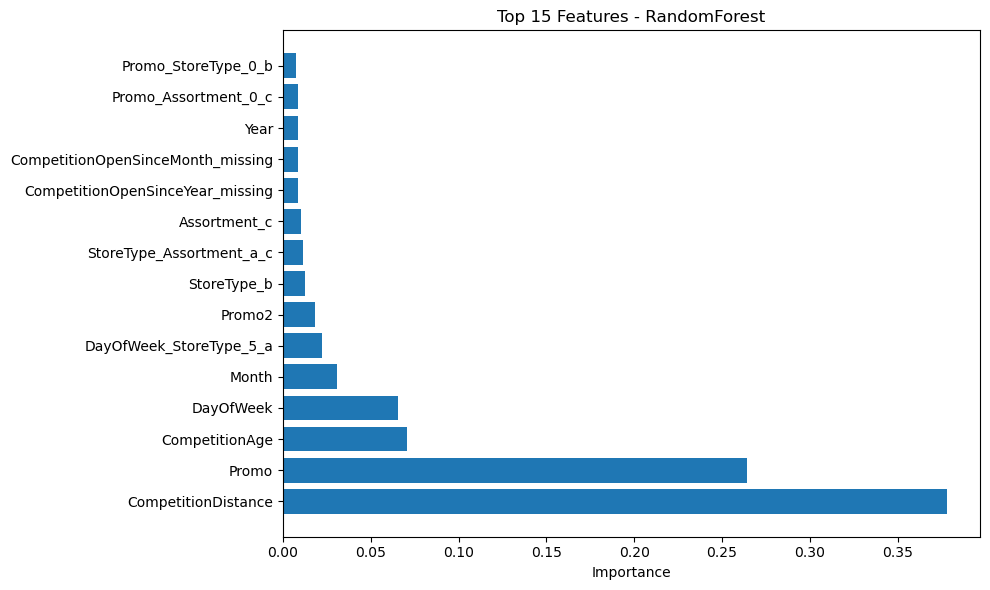

In [13]:
# 🎯 Analyse d'importance des features (si RandomForest ou GradientBoosting)

print("\n" + "="*70)
print("🎯 IMPORTANCE DES FEATURES (Top 15)")
print("="*70)

if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)
    
    print(feature_importance.to_string(index=False))
    
    # Plot
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(feature_importance)), feature_importance['Importance'])
    plt.yticks(range(len(feature_importance)), feature_importance['Feature'])
    plt.xlabel('Importance')
    plt.title(f'Top 15 Features - {best_model_name}')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Le modèle sélectionné ne supporte pas l'analyse d'importance des features")